In [2]:
import pandas as pd
import numpy as np
from datetime import datetime

# Carga de datos
try:
    df_empleados = pd.read_csv('empleados_mensual.csv', encoding='latin1')
except:
    df_empleados = pd.read_csv('empleados_mensual.csv', encoding='utf-8-sig')

# --- DEFINICIÓN DE LA FUNCIÓN DE LIMPIEZA ---
def arreglar_caracteres_raros(df):
    reemplazos = {
        'Ã¡': 'á', 'Ã©': 'é', 'Ã\xad': 'í', 'Ã-': 'í',
        'Ã³': 'ó', 'Ãº': 'ú', 'Ã±': 'ñ', 'Ã\x81': 'Á', 'Ã': 'Á',
    }
    # 1. Columnas
    for mal, bien in reemplazos.items():
        df.columns = df.columns.str.replace(mal, bien, regex=False)
    # 2. Contenido
    columnas_texto = df.select_dtypes(include=['object']).columns
    for col in columnas_texto:
        for mal, bien in reemplazos.items():
            df[col] = df[col].str.replace(mal, bien, regex=False)
    return df

# --- APLICAMOS LA FUNCIÓN ---
df_empleados = arreglar_caracteres_raros(df_empleados)

# --- 2. Pasar a formato fecha ---
columnas_fecha = ['mes_snapshot', 'fecha_nacimiento', 'fecha_ingreso', 'fecha_salida']
for col in columnas_fecha:
    df_empleados[col] = pd.to_datetime(df_empleados[col], errors='coerce')

# --- DEFINIR FECHA ACTUAL GLOBAL ---
fecha_actual = df_empleados['mes_snapshot'].max() + pd.offsets.MonthEnd(0)
print(f"Fecha de referencia (actual para análisis): {fecha_actual.date()}\n")

# --- FUNCIONES DE CHEQUEO (VALIDACIÓN HISTÓRICA EXACTA) ---
print("--- RESULTADOS DEL ANÁLISIS DE CALIDAD ---")

# 3. Duplicados
duplicados = df_empleados.duplicated(subset=['empleado_id', 'mes_snapshot']).sum()
print(f"3. Duplicados de ID por mes: {duplicados}")

# 4. Género
genero_raro = df_empleados[~df_empleados['genero'].isin(['M', 'F'])].shape[0]
print(f"4. Registros con género no válido: {genero_raro}")

# --- PREPARACIÓN PARA CÁLCULOS DINÁMICOS ---
# Referencia fila por fila (Fin de mes de cada snapshot)
referencia_fila = df_empleados['mes_snapshot'] + pd.offsets.MonthEnd(0)

# 5 y 6. Edad (Cálculo Dinámico)
diff_anios = referencia_fila.dt.year - df_empleados['fecha_nacimiento'].dt.year
# Ajuste si no cumplió años aún en ese mes/día
no_cumplio_aun = (
    (df_empleados['fecha_nacimiento'].dt.month > referencia_fila.dt.month) |
    ((df_empleados['fecha_nacimiento'].dt.month == referencia_fila.dt.month) &
     (df_empleados['fecha_nacimiento'].dt.day > referencia_fila.dt.day))
)
df_empleados['edad_calculada'] = diff_anios - no_cumplio_aun

edad_menor_18 = df_empleados[df_empleados['edad_calculada'] < 18].shape[0]
edad_inconsistente = df_empleados[df_empleados['edad'] != df_empleados['edad_calculada']].shape[0]
print(f"5. Empleados menores de 18 años: {edad_menor_18}")
print(f"6. Inconsistencias entre columna 'edad' y fecha de nacimiento: {edad_inconsistente}")

# 7. Antigüedad (CORREGIDO: Lógica SIFECHA / DATEDIF "M")
# Fórmula: (Años Diferencia * 12) + Meses Diferencia - Ajuste si el día de ingreso es mayor al día de corte
anios_ant = referencia_fila.dt.year - df_empleados['fecha_ingreso'].dt.year
meses_ant = referencia_fila.dt.month - df_empleados['fecha_ingreso'].dt.month
ajuste_dias = (df_empleados['fecha_ingreso'].dt.day > referencia_fila.dt.day)

df_empleados['antiguedad_calc'] = (anios_ant * 12) + meses_ant - ajuste_dias

# Tolerancia 0 o 1 (Excel a veces difiere por 1 mes dependiendo si considera el día inclusivo o no)
antiguedad_error = df_empleados[abs(df_empleados['antiguedad_meses'] - df_empleados['antiguedad_calc']) > 0].shape[0]
print(f"7. Inconsistencias en meses de antigüedad: {antiguedad_error}")

# 8. Activos con salida
error_salida = df_empleados[(df_empleados['activo'] == True) & (df_empleados['fecha_salida'].notnull())].shape[0]
print(f"8. Personas activas que tienen fecha de salida: {error_salida}")

# 9. Jubilación (CORREGIDO: Lógica SIFECHA hasta los 65 años exactos)
# Calculamos fecha exacta de jubilación (Nacimiento + 65 años)
# Nota: sumamos 65 al año. Mantenemos mes y día.
anio_jubilacion = df_empleados['fecha_nacimiento'].dt.year + 65
mes_jubilacion = df_empleados['fecha_nacimiento'].dt.month
dia_jubilacion = df_empleados['fecha_nacimiento'].dt.day

# Calculamos meses desde la referencia HASTA la fecha de jubilación
# (Año Jub - Año Ref)*12 + (Mes Jub - Mes Ref) - Ajuste Días
anios_hasta = anio_jubilacion - referencia_fila.dt.year
meses_hasta = mes_jubilacion - referencia_fila.dt.month
# Ajuste: Si el día de jubilación (cumpleaños) es MENOR al día de referencia (fin de mes), ya pasó un mes incompleto
ajuste_dias_jub = (dia_jubilacion < referencia_fila.dt.day)

# Fórmula final y aseguramos que no de negativo
df_empleados['jubilacion_calc'] = (anios_hasta * 12) + meses_hasta - ajuste_dias_jub
df_empleados['jubilacion_calc'] = df_empleados['jubilacion_calc'].apply(lambda x: max(x, 0))

error_jubilacion = df_empleados[(df_empleados['activo'] == True) &
                                (df_empleados['meses_hasta_jubilacion'] != df_empleados['jubilacion_calc'])].shape[0]
print(f"9. Errores en meses hasta jubilación (Ref. 65 años): {error_jubilacion}")

# 10. Años en puesto
error_años_puesto = df_empleados[df_empleados['años_en_puesto_actual'].astype(float) > (df_empleados['antiguedad_meses']/12 + 0.1)].shape[0]
print(f"10. Años en puesto mayores a antigüedad total: {error_años_puesto}")

Fecha de referencia (actual para análisis): 2025-05-31

--- RESULTADOS DEL ANÁLISIS DE CALIDAD ---
3. Duplicados de ID por mes: 0
4. Registros con género no válido: 0
5. Empleados menores de 18 años: 0
6. Inconsistencias entre columna 'edad' y fecha de nacimiento: 5295
7. Inconsistencias en meses de antigüedad: 4312
8. Personas activas que tienen fecha de salida: 0
9. Errores en meses hasta jubilación (Ref. 65 años): 9600
10. Años en puesto mayores a antigüedad total: 0


In [3]:
# --- CORRECCIÓN DE GÉNEROS ERRÓNEOS ---
# Basado en el análisis manual del listado de nombres proporcionado

def corregir_genero_por_nombre(df):
    # Lista de nombres que DEBEN ser Masculinos (M) pero aparecen como F
    # (Extraídos con IA desde el listado de nombres completos. Nombre es masculino y genero='F')
    nombres_a_masculino = [
        "Damián Alberto", "Isaías Andrés", "Mario Alberto", "Bruno Roberto",
        "Damián Jorge", "Manuel Jorge", "Rodrigo Jorge", "Luis Roberto",
        "Jorge Alejandro", "Lorenzo Marcelo", "Alan Juan", "Alfredo Carlos",
        "Fernando Alejandro", "Adrián Alberto", "Facundo Miguel", "Guillermo",
        "Joaquín Jorge", "Adrián José", "Luciano Andrés", "Francisco Carlos",
        "Elías Daniel", "Benjamín Marcelo", "Juan Alberto", "Nicolás Andrés",
        "Elías Gustavo", "Ignacio Pablo", "Benjamín Fernando", "Bruno Alberto",
        "David Sergio", "Adrián Miguel", "Roberto Juan", "Santiago Carlos",
        "Luciano Juan", "Cristian Jorge", "Raúl Roberto", "Walter", "Julián Pablo",
        "Fernando Daniel", "Gabriel Juan", "Héctor Martín", "Carlos Fernando",
        # Agregamos algunos que vi en tu lista que podrían ser ambiguos pero en este dataset son errores
        "Ramiro Luis"
    ]

    # Lista de nombres que DEBEN ser Femeninos (F) pero aparecen como M
    # (Extraídos con IA desde el listado de nombres completos. Nombre es femenino y genero='M')
    # (La IA no encontró ningún nombre en el listado que sea femenino y genero='M')
    nombres_a_femenino = [
        # Si se encuentra alguno en el futuro, agregar aquí.
    ]

    # Aplicamos la corrección
    # 1. Corrección a Masculino
    mask_m = df['nombre'].isin(nombres_a_masculino)
    df.loc[mask_m, 'genero'] = 'M'

    # 2. Corrección a Femenino
    mask_f = df['nombre'].isin(nombres_a_femenino)
    df.loc[mask_f, 'genero'] = 'F'

    print(f"--- CORRECCIÓN DE GÉNERO ---")
    print(f"Se corrigieron {mask_m.sum()} registros de F -> M")
    print(f"Se corrigieron {mask_f.sum()} registros de M -> F")

    return df

# APLICAR LA CORRECCIÓN
df_empleados = corregir_genero_por_nombre(df_empleados)

# Chequeo rápido post-corrección
print("\nVerificación de casos corregidos (Ejemplo: Damián Alberto):")
try:
    ejemplo = df_empleados[df_empleados['nombre'] == 'Damián Alberto'][['nombre', 'genero']].iloc[0]
    print(f"{ejemplo['nombre']} -> {ejemplo['genero']}")
except:
    print("Ejemplo no encontrado (quizás ya se filtró o cambió).")

--- CORRECCIÓN DE GÉNERO ---
Se corrigieron 714 registros de F -> M
Se corrigieron 0 registros de M -> F

Verificación de casos corregidos (Ejemplo: Damián Alberto):
Damián Alberto -> M


In [4]:
# 1. Crear tabla Headcount Actual
# CORRECCIÓN: Usamos .max() directo de la columna para encontrar la etiqueta "2025-05-01"
# independientemente de que nuestra fecha_actual de análisis sea el 31.
ultima_fecha_disponible = df_empleados['mes_snapshot'].max()

headcount_actual = df_empleados[
    (df_empleados['mes_snapshot'] == ultima_fecha_disponible) &
    (df_empleados['activo'] == True)
].copy()

# Seleccionar solo las columnas de información personal
columnas_hc_actual = [
    "empleado_id","mes_snapshot","activo","nombre","genero","edad","fecha_nacimiento",
    "fecha_ingreso","antiguedad_meses","fecha_salida","motivo_salida","area",
    "subarea","puesto","nivel_jerarquico","categoria_collar","manager_id",
    "manager_nombre","span_of_control","es_posicion_critica","meses_hasta_jubilacion",
    "años_en_puesto_actual"
]

# Nota: Si alguna columna no existe (como 'edad' que borramos antes para recalcular),
# usamos intersection para evitar errores, o nos aseguramos de que existan.
cols_existentes = [c for c in columnas_hc_actual if c in headcount_actual.columns]
headcount_actual = headcount_actual[cols_existentes]

print(f"--- Reporte de Headcount Actual con información personal ---")
# Mostramos la fecha de etiqueta (01) y la cantidad
print(f"Snapshot utilizado: {ultima_fecha_disponible.date()}")
print(f"Cantidad de personas activas: {len(headcount_actual)}")

# 2. Crear tabla Headcount Acumulado (Historia de los que hoy están activos)
# Obtenemos la lista de IDs de las personas que están activas hoy
ids_activos_hoy = headcount_actual['empleado_id'].unique()

# Filtramos la tabla original para que solo contenga a esas personas (toda su historia mensual)
headcount_acumulado = df_empleados[df_empleados['empleado_id'].isin(ids_activos_hoy)].copy()

print(f"\n--- Reporte de Headcount Acumulado ---")
print(f"Total de registros históricos de empleados actualmente activos: {len(headcount_acumulado)}")

if len(ids_activos_hoy) > 0:
    print(f"Promedio de meses de historia por empleado: {len(headcount_acumulado)/len(ids_activos_hoy):.1f}")
else:
    print("ALERTA: No se encontraron empleados activos. Revisa el filtro de fechas.")

# Opcional: Guardar a CSV
headcount_actual.to_csv('headcount_actual.csv', index=False)
headcount_acumulado.to_csv('headcount_acumulado.csv', index=False)

--- Reporte de Headcount Actual con información personal ---
Snapshot utilizado: 2025-05-01
Cantidad de personas activas: 562

--- Reporte de Headcount Acumulado ---
Total de registros históricos de empleados actualmente activos: 8638
Promedio de meses de historia por empleado: 15.4


In [5]:
import pandas as pd

# 0. Cargar el archivo de capacitaciones
try:
    df_capacitaciones = pd.read_csv('capacitaciones.csv', encoding='latin1')
except:
    df_capacitaciones = pd.read_csv('capacitaciones.csv', encoding='utf-8-sig')

# --- APLICAR LA FUNCIÓN DE LIMPIEZA DE CARACTERES ---
# (Asume que ya se definió la función 'arreglar_caracteres_raros' en el paso anterior)
df_capacitaciones = arreglar_caracteres_raros(df_capacitaciones)

# 2. Pasar a formato fecha
df_capacitaciones['fecha_inicio'] = pd.to_datetime(df_capacitaciones['fecha_inicio'], errors='coerce')
df_capacitaciones['fecha_fin'] = pd.to_datetime(df_capacitaciones['fecha_fin'], errors='coerce')

print("--- RESULTADOS DEL ANÁLISIS DE CALIDAD (CAPACITACIONES) ---")

# 3. Duplicados en ID de capacitaciones
duplicados_cap = df_capacitaciones.duplicated(subset=['training_id']).sum()
print(f"3. Duplicados de ID de capacitación: {duplicados_cap}")

# 4. Fecha de fin posterior o igual a la de inicio
error_fechas_orden = df_capacitaciones[df_capacitaciones['fecha_fin'] < df_capacitaciones['fecha_inicio']].shape[0]
print(f"4. Capacitaciones con fecha de fin anterior al inicio (Error): {error_fechas_orden}")

# 5. mes_training coincide con fecha_fin
df_capacitaciones['mes_fin_calc'] = df_capacitaciones['fecha_fin'].dt.strftime('%Y-%m')
error_mes_training = df_capacitaciones[df_capacitaciones['mes_training'] != df_capacitaciones['mes_fin_calc']].shape[0]
print(f"5. Inconsistencias entre mes_training y fecha_fin: {error_mes_training}")

# 6. Capacitaciones futuras (Usamos fecha_actual del paso anterior)
# Nota: Si da error de 'fecha_actual not defined', asegúrate de correr el bloque de Empleados primero.
error_fecha_futura = df_capacitaciones[
    (df_capacitaciones['completado'] == True) &
    (df_capacitaciones['fecha_fin'] > fecha_actual)
].shape[0]
print(f"6. Capacitaciones 'completadas' con fecha de fin posterior a hoy: {error_fecha_futura}")

# 7. Modalidad válida
modalidades_validas = ['Presencial', 'Mixto', 'Online']
error_modalidad = df_capacitaciones[~df_capacitaciones['modalidad'].str.strip().isin(modalidades_validas)].shape[0]
print(f"7. Registros con modalidades no válidas: {error_modalidad}")

--- RESULTADOS DEL ANÁLISIS DE CALIDAD (CAPACITACIONES) ---
3. Duplicados de ID de capacitación: 0
4. Capacitaciones con fecha de fin anterior al inicio (Error): 0
5. Inconsistencias entre mes_training y fecha_fin: 29
6. Capacitaciones 'completadas' con fecha de fin posterior a hoy: 6
7. Registros con modalidades no válidas: 19


In [6]:
# 1. Crear tabla Capacitaciones actual
# Filtramos:
# - Que el empleado esté en el Headcount Actual (ids_activos_hoy)
# - Que la capacitación esté completada
# - Que haya terminado antes o en la fecha actual (snapshot)
capacitaciones_actual = df_capacitaciones[
    (df_capacitaciones['empleado_id'].isin(ids_activos_hoy)) &
    (df_capacitaciones['completado'] == True) &
    (df_capacitaciones['fecha_fin'] <= fecha_actual)
].copy()

# Mostrar resultados
print(f"--- Reporte de Capacitaciones Actual ---")
print(f"Total de capacitaciones válidas para el personal activo: {len(capacitaciones_actual)}")
print(f"Empleados únicos que han completado al menos un curso: {capacitaciones_actual['empleado_id'].nunique()}")

# Guardar
capacitaciones_actual.to_csv('capacitaciones_actual.csv', index=False)

--- Reporte de Capacitaciones Actual ---
Total de capacitaciones válidas para el personal activo: 561
Empleados únicos que han completado al menos un curso: 399


In [7]:
import pandas as pd

# 0. Cargar el archivo de eventos
try:
    df_eventos = pd.read_csv('eventos_rrhh.csv', encoding='latin1')
except:
    df_eventos = pd.read_csv('eventos_rrhh.csv', encoding='utf-8-sig')

# --- APLICAR LA FUNCIÓN DE LIMPIEZA DE CARACTERES ---
# (Asume que ya definiste la función 'arreglar_caracteres_raros' en el bloque de Empleados)
df_eventos = arreglar_caracteres_raros(df_eventos)

# 2. Pasar a formato fecha la columna principal 'fecha_evento'
# Usamos dayfirst=True para asegurar que 01/05 sea 1 de Mayo y no 5 de Enero
df_eventos['fecha_evento'] = pd.to_datetime(df_eventos['fecha_evento'], dayfirst=True, errors='coerce')

print("--- RESULTADOS DEL ANÁLISIS DE CALIDAD (EVENTOS) ---")

# 3. Duplicados en ID de eventos
duplicados_ev = df_eventos.duplicated(subset=['evento_id']).sum()
print(f"3. Duplicados de ID de evento: {duplicados_ev}")

# 4 y 6. Chequear formato y consistencia de mes_evento
# --- CORRECCIÓN: Función flexible para leer ambos formatos (con / y con -) ---
def leer_fecha_flexible(valor):
    valor_str = str(valor).strip()
    try:
        # Si detectamos barras (23/1/2024), forzamos día primero
        if '/' in valor_str:
            fecha = pd.to_datetime(valor_str, dayfirst=True)
        # Si no (2025-04 o 2024-01-01), dejamos que pandas decida (formato ISO estándar)
        else:
            fecha = pd.to_datetime(valor_str)

        return fecha.strftime('%Y-%m')
    except:
        return None

# Aplicamos la función fila por fila
df_eventos['mes_evento_normalizado'] = df_eventos['mes_evento'].apply(leer_fecha_flexible)

# Columna de control (fecha real)
df_eventos['mes_real_evento'] = df_eventos['fecha_evento'].dt.strftime('%Y-%m')

# Recalculamos errores
error_formato_mes = df_eventos['mes_evento_normalizado'].isnull().sum()

# Comparamos (rellenando nulos con 'X' para que la comparación no falle)
error_consistencia_mes = df_eventos[
    df_eventos['mes_evento_normalizado'].fillna('X') != df_eventos['mes_real_evento'].fillna('X')
].shape[0]

print(f"4. Registros con mes_evento en formato irreconocible: {error_formato_mes}")
print(f"6. Inconsistencias entre mes_evento y la fecha real del evento: {error_consistencia_mes}")

# 5. Fecha del evento posterior a la fecha actual
try:
    error_fecha_futura_ev = df_eventos[df_eventos['fecha_evento'] > fecha_actual].shape[0]
    print(f"5. Eventos con fecha posterior a la actualidad ({fecha_actual.date()}): {error_fecha_futura_ev}")
except NameError:
    print("5. No se pudo chequear fecha futura (falta correr bloque de Empleados).")

/tmp/ipython-input-3726412163.py:15: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_eventos['fecha_evento'] = pd.to_datetime(df_eventos['fecha_evento'], dayfirst=True, errors='coerce')


--- RESULTADOS DEL ANÁLISIS DE CALIDAD (EVENTOS) ---
3. Duplicados de ID de evento: 0
4. Registros con mes_evento en formato irreconocible: 0
6. Inconsistencias entre mes_evento y la fecha real del evento: 1
5. Eventos con fecha posterior a la actualidad (2025-05-31): 0


In [8]:
# 1. Crear tabla Eventos actual
# Filtramos:
# - Que el empleado pertenezca al Headcount Actual (ids_activos_hoy)
# - Que la fecha del evento sea menor o igual a la fecha de corte (fecha_actual)

try:
    eventos_actual = df_eventos[
        (df_eventos['empleado_id'].isin(ids_activos_hoy)) &
        (df_eventos['fecha_evento'] <= fecha_actual)
    ].copy()

    # --- CORRECCIÓN: Usar la columna de mes limpia ---
    # Reemplazamos la columna 'mes_evento' original con la normalizada
    eventos_actual['mes_evento'] = eventos_actual['mes_evento_normalizado']

    # Eliminamos las columnas auxiliares de cálculo para que el Excel final quede limpio
    eventos_actual = eventos_actual.drop(columns=['mes_evento_normalizado', 'mes_real_evento'], errors='ignore')

    print(f"--- Reporte de Eventos Actual ---")
    print(f"Total de eventos registrados para el personal activo: {len(eventos_actual)}")
    print(f"Tipos de eventos encontrados: {eventos_actual['tipo_evento'].unique()}")

    # Guardar
    eventos_actual.to_csv('eventos_actual.csv', index=False)

except NameError:
    print("Error: Faltan variables (ids_activos_hoy o fecha_actual). Asegúrate de correr el bloque de Empleados primero.")

--- Reporte de Eventos Actual ---
Total de eventos registrados para el personal activo: 7324
Tipos de eventos encontrados: ['contratacion' 'onboarding' 'evaluacion' 'ausencia' 'incidente_seguridad']


In [9]:
import pandas as pd
from google.colab import files

# Nombre del archivo final
nombre_archivo = 'Datos_Limpios_TechnoStamp.xlsx'

print("Generando archivo Excel...")

# Usamos ExcelWriter para escribir múltiples hojas en un solo archivo
try:
    with pd.ExcelWriter(nombre_archivo, engine='openpyxl') as writer:

        # 1. Hoja Headcount Actual (La foto de hoy)
        headcount_actual.to_excel(writer, sheet_name='HC Actual', index=False)

        # 2. Hoja Headcount Acumulado (La historia de los activos)
        headcount_acumulado.to_excel(writer, sheet_name='HC Acumulado', index=False)

        # 3. Hoja Capacitaciones (Solo las válidas de gente activa)
        capacitaciones_actual.to_excel(writer, sheet_name='Capacitaciones', index=False)

        # 4. Hoja Eventos (Solo los históricos de gente activa)
        eventos_actual.to_excel(writer, sheet_name='Eventos', index=False)

    print(f"Archivo '{nombre_archivo}' creado exitosamente.")

    # Descargar el archivo a tu computadora
    files.download(nombre_archivo)

except NameError as e:
    print("ERROR: Alguna de las tablas no está definida.")
    print("Asegúrate de haber corrido los bloques de código anteriores para crear:")
    print("- headcount_actual")
    print("- headcount_acumulado")
    print("- capacitaciones_actual")
    print("- eventos_actual")
    print(f"Detalle del error: {e}")

except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Generando archivo Excel...
Archivo 'Datos_Limpios_TechnoStamp.xlsx' creado exitosamente.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# --- VALIDACIÓN CRUZADA INTELIGENTE: CAPACITACIONES VS HC ACUMULADO ---

# 1. Obtener datos (Igual que antes)
hc_last_state = headcount_acumulado.sort_values('mes_snapshot').groupby('empleado_id').tail(1).copy()
hc_audit_cap = hc_last_state[['empleado_id', 'nombre', 'ultimo_training_fecha']].copy()
hc_audit_cap['ultimo_training_fecha'] = pd.to_datetime(hc_audit_cap['ultimo_training_fecha'], errors='coerce')

real_training = capacitaciones_actual.groupby('empleado_id')['fecha_fin'].max().reset_index()
real_training.rename(columns={'fecha_fin': 'fecha_real_max'}, inplace=True)

audit_cap = pd.merge(hc_audit_cap, real_training, on='empleado_id', how='left')

# 2. Calcular diferencia
audit_cap['diferencia_dias'] = (audit_cap['ultimo_training_fecha'] - audit_cap['fecha_real_max']).dt.days

# --- NUEVA LÓGICA DE VALIDACIÓN ---

# CASO 1: Falso Positivo (HC dice que hubo training, pero no está en la lista de trainings)
# Este sigue siendo un error grave.
error_sin_respaldo = audit_cap[
    (audit_cap['ultimo_training_fecha'].notnull()) &
    (audit_cap['fecha_real_max'].isnull())
]

# CASO 2: Discrepancia de Fechas (Aplicando Regla de Negocio)
# Filtramos solo los que tienen ambas fechas
con_datos = audit_cap.dropna(subset=['ultimo_training_fecha', 'fecha_real_max'])

# Definimos qué es aceptable:
# - Aceptable: Que la fecha de HC sea hasta 31 días menor a la fecha de capacitación registrada (debe cubrir el mes completo)
# - Aceptable: Que la fecha de HC sea MAYOR a la Real pero por menos de 31 días (Latencia de reporte mensual)
# - ERROR: Que la fecha de HC sea MENOR a la Real (diferencia negativa -> El sistema predijo el futuro?)
# - ERROR: Que la fecha de HC sea MAYOR por más de 40 días (El sistema tardó 2 meses en actualizar o está mal)

errores_reales_fecha = con_datos[
    ~((con_datos['diferencia_dias'] >= -31) & (con_datos['diferencia_dias'] <= 31))
]

print("--- RESULTADOS AUDITORÍA AJUSTADA (Con Tolerancia de Reporte) ---")
print(f"1. HC indica capacitación sin respaldo en planilla: {len(error_sin_respaldo)}")
print(f"2. Fechas que no cumplen la lógica de 'reporte mes siguiente': {len(errores_reales_fecha)}")

if len(errores_reales_fecha) > 0:
    print("\nEjemplos de ERRORES REALES (Fuera de la tolerancia de 40 días):")
    display(errores_reales_fecha.head())
else:
    print("\n¡Perfecto! Todas las diferencias de fechas se explican por la lógica de reporte mensual.")

--- RESULTADOS AUDITORÍA AJUSTADA (Con Tolerancia de Reporte) ---
1. HC indica capacitación sin respaldo en planilla: 5
2. Fechas que no cumplen la lógica de 'reporte mes siguiente': 35

Ejemplos de ERRORES REALES (Fuera de la tolerancia de 40 días):


,empleado_id,nombre,ultimo_training_fecha,fecha_real_max,diferencia_dias
22,1663,Ricardo,2025-05-01,2025-03-20,42.0
25,1670,Roberto,2025-05-01,2025-03-23,39.0
27,1658,Laura,2025-05-01,2025-03-15,47.0
28,1669,Luis,2025-05-01,2025-03-17,45.0
46,1665,Roberto,2025-05-01,2025-03-30,32.0


In [11]:
# --- VALIDACIÓN CRUZADA: EVENTOS VS HC ACUMULADO (MES A MES) ---

# 1. Preparar HC Acumulado (La versión oficial de RRHH)
df_hc_mes = headcount_acumulado.copy()
# Normalizamos el mes para poder cruzar (YYYY-MM)
df_hc_mes['mes_join'] = df_hc_mes['mes_snapshot'].dt.strftime('%Y-%m')

# Seleccionamos solo las columnas métricas y rellenamos nulos con 0
df_hc_metrics = df_hc_mes[['empleado_id', 'nombre', 'mes_join', 'dias_ausente', 'incidentes_seguridad_count']].fillna(0)

# 2. Preparar Eventos (La realidad operativa)

# A. Calcular Ausencias por mes y empleado
# Filtramos solo eventos de 'ausencia' y sumamos los 'dias_perdidos'
ausencias_reales = eventos_actual[eventos_actual['tipo_evento'] == 'ausencia'].groupby(
    ['empleado_id', 'mes_evento']
)['dias_perdidos'].sum().reset_index()
ausencias_reales.rename(columns={'dias_perdidos': 'ausencias_calc', 'mes_evento': 'mes_join'}, inplace=True)

# B. Calcular Incidentes por mes y empleado
# Filtramos 'incidente_seguridad' y contamos cuántos ocurrieron (.size)
seguridad_real = eventos_actual[eventos_actual['tipo_evento'] == 'incidente_seguridad'].groupby(
    ['empleado_id', 'mes_evento']
).size().reset_index(name='incidentes_calc')
seguridad_real.rename(columns={'mes_evento': 'mes_join'}, inplace=True)

# 3. Unificar todo en una tabla de auditoría
# Unimos HC con Ausencias Reales
chequeo = pd.merge(df_hc_metrics, ausencias_reales, on=['empleado_id', 'mes_join'], how='left')
# Unimos con Seguridad Real
chequeo = pd.merge(chequeo, seguridad_real, on=['empleado_id', 'mes_join'], how='left')

# Rellenamos nulos con 0 (Si no cruza, significa que hubo 0 eventos en la planilla operativa)
chequeo[['ausencias_calc', 'incidentes_calc']] = chequeo[['ausencias_calc', 'incidentes_calc']].fillna(0)

# 4. Calcular Diferencias

# Chequeo 1: Ausencias
chequeo['diff_ausencias'] = chequeo['dias_ausente'] - chequeo['ausencias_calc']
errores_ausencia = chequeo[chequeo['diff_ausencias'] != 0]

# Chequeo 2: Seguridad
chequeo['diff_seguridad'] = chequeo['incidentes_seguridad_count'] - chequeo['incidentes_calc']
errores_seguridad = chequeo[chequeo['diff_seguridad'] != 0]

print("--- RESULTADOS AUDITORÍA: EVENTOS (Mes a Mes) ---")
print(f"Total registros mensuales auditados: {len(chequeo)}")
print(f"1. Meses con discrepancia en Días Ausentes: {len(errores_ausencia)}")
print(f"2. Meses con discrepancia en Conteo Incidentes: {len(errores_seguridad)}")

if len(errores_ausencia) > 0:
    print("\nEjemplo Top 5 Discrepancias en Ausencias:")
    display(errores_ausencia[['nombre', 'mes_join', 'dias_ausente', 'ausencias_calc', 'diff_ausencias']].head())

if len(errores_seguridad) > 0:
    print("\nEjemplo Top 5 Discrepancias en Seguridad:")
    display(errores_seguridad[['nombre', 'mes_join', 'incidentes_seguridad_count', 'incidentes_calc', 'diff_seguridad']].head())

--- RESULTADOS AUDITORÍA: EVENTOS (Mes a Mes) ---
Total registros mensuales auditados: 8638
1. Meses con discrepancia en Días Ausentes: 2482
2. Meses con discrepancia en Conteo Incidentes: 54

Ejemplo Top 5 Discrepancias en Ausencias:


,nombre,mes_join,dias_ausente,ausencias_calc,diff_ausencias
1,Paola,2024-02,2.0,0.0,2.0
2,Paola,2024-03,1.0,4.0,-3.0
19,Paula Silvia,2024-03,2.0,4.0,-2.0
35,Claudia Sandra,2024-02,3.0,0.0,3.0
36,Claudia Sandra,2024-03,1.0,2.0,-1.0



Ejemplo Top 5 Discrepancias en Seguridad:


,nombre,mes_join,incidentes_seguridad_count,incidentes_calc,diff_seguridad
2756,Ezequiel Andrés,2024-02,1,0.0,1.0
3197,Gerardo José,2024-02,1,0.0,1.0
3571,Benjamín Marcelo,2024-02,1,0.0,1.0
3572,Benjamín Marcelo,2024-03,1,0.0,1.0
3573,Benjamín Marcelo,2024-04,1,0.0,1.0


In [12]:
import pandas as pd

# 1. Preparar los datos frescos desde el Headcount Actual
df_sucesion = headcount_actual.copy()

# 2. Calcular Edad EXACTA (Coherencia con Bloque 1)
# Usamos fecha_actual (que ya definimos como 2025-05-31)
diff_anios = fecha_actual.year - df_sucesion['fecha_nacimiento'].dt.year

# Ajuste: ¿Ya cumplió años a la fecha de corte?
no_cumplio_aun = (
    (df_sucesion['fecha_nacimiento'].dt.month > fecha_actual.month) |
    ((df_sucesion['fecha_nacimiento'].dt.month == fecha_actual.month) &
     (df_sucesion['fecha_nacimiento'].dt.day > fecha_actual.day))
)

df_sucesion['edad_real'] = diff_anios - no_cumplio_aun
df_sucesion['años_para_jubilacion'] = 65 - df_sucesion['edad_real']

# 3. Filtrar SOLO Posiciones Críticas
df_criticos = df_sucesion[df_sucesion['es_posicion_critica'] == True].copy()

# --- DEFINICIÓN DE LA LÓGICA DE REEMPLAZO (CORREGIDA Y PRECISA) ---
def buscar_reemplazo_experto(fila, df_total):
    """
    Busca un empleado activo que:
    1. Sea de la misma Area, Subarea y Puesto.
    2. No sea la misma persona que se jubila.
    3. Tenga la mayor antigüedad.
    """
    candidatos = df_total[
        (df_total['area'] == fila['area']) &
        (df_total['subarea'] == fila['subarea']) &
        (df_total['puesto'] == fila['puesto']) &
        (df_total['empleado_id'] != fila['empleado_id'])
    ].sort_values('fecha_ingreso', ascending=True)

    if len(candidatos) > 0:
        mejor_candidato = candidatos.iloc[0]

        # --- CORRECCIÓN DE ANTIGÜEDAD (Lógica Calendario Exacta) ---
        # Calculamos años exactos de experiencia del candidato
        anios_exp = fecha_actual.year - mejor_candidato['fecha_ingreso'].year
        # Ajuste si no cumplió el aniversario de ingreso aún
        falta_aniversario = (
            (mejor_candidato['fecha_ingreso'].month > fecha_actual.month) |
            ((mejor_candidato['fecha_ingreso'].month == fecha_actual.month) &
             (mejor_candidato['fecha_ingreso'].day > fecha_actual.day))
        )
        antiguedad_reemplazo = anios_exp - falta_aniversario

        return f"{mejor_candidato['nombre']} (ID: {mejor_candidato['empleado_id']} - Antig: {antiguedad_reemplazo} años)"
    else:
        return "VACANTE / SIN REEMPLAZO DIRECTO"

# 4. Generar las dos listas solicitadas

# LISTA A: Próximos 12 Meses (<= 1 año)
# Nota: Incluimos a los que ya tienen >= 65 años (valores negativos o 0)
jubilables_12_meses = df_criticos[df_criticos['años_para_jubilacion'] <= 1].copy()

if not jubilables_12_meses.empty:
    jubilables_12_meses['posible_reemplazo'] = jubilables_12_meses.apply(
        lambda x: buscar_reemplazo_experto(x, df_sucesion), axis=1
    )

# LISTA B: Próximos 12 a 24 Meses (> 1 y <= 2 años)
jubilables_24_meses = df_criticos[
    (df_criticos['años_para_jubilacion'] > 1) &
    (df_criticos['años_para_jubilacion'] <= 2)
].copy()

if not jubilables_24_meses.empty:
    jubilables_24_meses['posible_reemplazo'] = jubilables_24_meses.apply(
        lambda x: buscar_reemplazo_experto(x, df_sucesion), axis=1
    )

# 5. Mostrar Resultados
cols_mostrar = ['empleado_id', 'nombre', 'area', 'puesto', 'edad_real', 'años_para_jubilacion', 'posible_reemplazo']

print(f"--- ANÁLISIS DE SUCESIÓN CRÍTICA (REGLA: PARES CON ANTIGÜEDAD EXACTA) ---\n")

print(f"1. ALERTA ROJA: Posiciones Críticas a jubilarse en < 12 meses ({len(jubilables_12_meses)} casos)")
if len(jubilables_12_meses) > 0:
    display(jubilables_12_meses[cols_mostrar])
else:
    print("No hay empleados críticos jubilándose en este periodo.")

print(f"\n2. ALERTA AMARILLA: Posiciones Críticas a jubilarse entre 12 y 24 meses ({len(jubilables_24_meses)} casos)")
if len(jubilables_24_meses) > 0:
    display(jubilables_24_meses[cols_mostrar])
else:
    print("No hay empleados críticos jubilándose en este periodo.")

--- ANÁLISIS DE SUCESIÓN CRÍTICA (REGLA: PARES CON ANTIGÜEDAD EXACTA) ---

1. ALERTA ROJA: Posiciones Críticas a jubilarse en < 12 meses (0 casos)
No hay empleados críticos jubilándose en este periodo.

2. ALERTA AMARILLA: Posiciones Críticas a jubilarse entre 12 y 24 meses (1 casos)


,empleado_id,nombre,area,puesto,edad_real,años_para_jubilacion,posible_reemplazo
1470,1098,Teresa,Estampado,Técnico Setup,63,2,Emilia Claudia (ID: 1017 - Antig: 10 años)


--- INICIANDO ANÁLISIS PREGUNTA 2: EFICIENCIA Y BIENESTAR (VERSIÓN FINAL) ---

--- TABLA RESUMEN: PRODUCTIVIDAD VS SALUD ---


,Nivel Horas Extra,Unidades Promedio,Scrap Promedio (%),Ausencias Promedio,Total Registros,Personas Únicas,% del Total Registros
0,Bajo (0-5h),995.31,1.87,0.90,1369,203,15.85
1,Medio (5-15h),981.23,2.28,0.82,6573,547,76.09
2,Alto (15-25h),974.13,2.37,0.71,677,198,7.84
3,Crítico (>25h),990.58,1.74,0.63,19,8,0.22


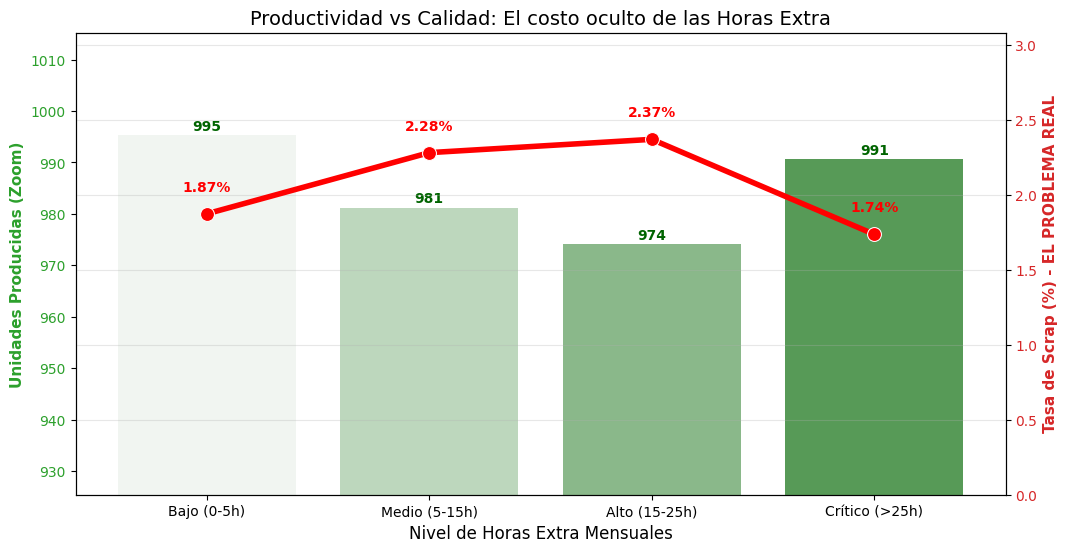

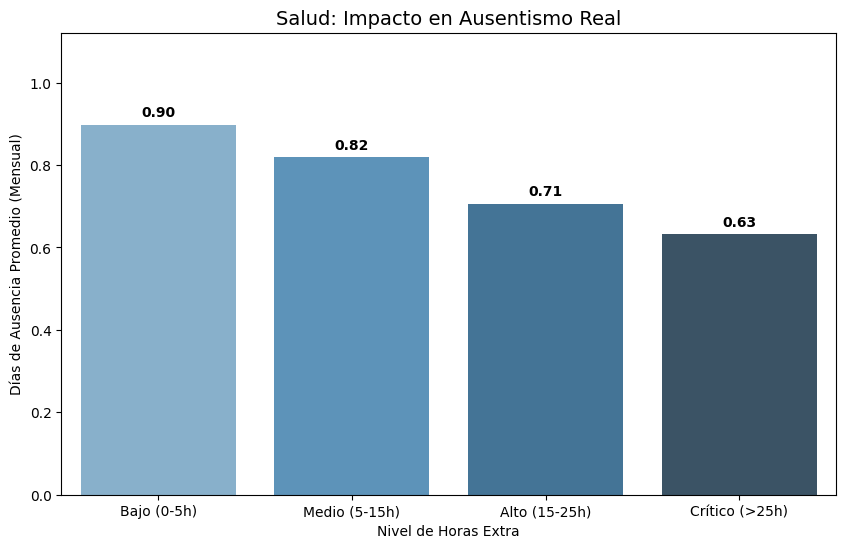

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INICIANDO ANÁLISIS PREGUNTA 2: EFICIENCIA Y BIENESTAR (VERSIÓN FINAL) ---\n")

# 1. Preparación de datos (HC Acumulado + Eventos Reales de Ausencia)
df_prod = headcount_acumulado.copy()
df_prod['mes_join'] = df_prod['mes_snapshot'].dt.strftime('%Y-%m')

# Agrupamos eventos de ausencia por mes y empleado
ausencias_mes = eventos_actual[eventos_actual['tipo_evento'] == 'ausencia'].groupby(
    ['empleado_id', 'mes_evento']
)['dias_perdidos'].sum().reset_index()
ausencias_mes.rename(columns={'mes_evento': 'mes_join', 'dias_perdidos': 'dias_ausente_real'}, inplace=True)

# Cruzamos la tabla madre con las ausencias reales
df_analisis_2 = pd.merge(df_prod, ausencias_mes, on=['empleado_id', 'mes_join'], how='left')
df_analisis_2['dias_ausente_real'] = df_analisis_2['dias_ausente_real'].fillna(0)

# 2. Crear Categorías de Sobrecarga (Buckets de Horas Extra)
bins = [-1, 5, 15, 25, 1000]
labels = ['Bajo (0-5h)', 'Medio (5-15h)', 'Alto (15-25h)', 'Crítico (>25h)']
df_analisis_2['nivel_horas_extra'] = pd.cut(df_analisis_2['horas_extra'], bins=bins, labels=labels)

# 3. Agregación de Datos (Promedios y Conteos)
# observed=False evita warnings en categorías vacías si las hubiera
resumen_carga = df_analisis_2.groupby('nivel_horas_extra', observed=False).agg({
    'unidades_producidas': 'mean',
    'tasa_scrap_porcentaje': 'mean',
    'dias_ausente_real': 'mean',
    'empleado_id': ['count', 'nunique'] # Count=Registros totales, Nunique=Personas distintas
}).reset_index()

# Aplanar nombres de columnas
resumen_carga.columns = [
    'Nivel Horas Extra', 'Unidades Promedio', 'Scrap Promedio (%)',
    'Ausencias Promedio', 'Total Registros', 'Personas Únicas'
]

# 4. Cálculos de Porcentajes para la tabla
total_registros = resumen_carga['Total Registros'].sum()
resumen_carga['% del Total Registros'] = (resumen_carga['Total Registros'] / total_registros) * 100

print("--- TABLA RESUMEN: PRODUCTIVIDAD VS SALUD ---")
display(resumen_carga.round(2))

# --- GRÁFICO 1: PRODUCTIVIDAD (CON ZOOM Y ÉNFASIS EN SCRAP) ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Configuración del ZOOM para las barras (Eje Y dinámico)
min_y = resumen_carga['Unidades Promedio'].min() * 0.95
max_y = resumen_carga['Unidades Promedio'].max() * 1.02

color = 'tab:green'
ax1.set_xlabel('Nivel de Horas Extra Mensuales', fontsize=12)
ax1.set_ylabel('Unidades Producidas (Zoom)', color=color, fontweight='bold', fontsize=11)

# Gráfico de Barras (Unidades) - FIX WARNING: agregamos hue y legend=False
sns.barplot(
    data=resumen_carga, x='Nivel Horas Extra', y='Unidades Promedio',
    hue='Nivel Horas Extra', legend=False, ax=ax1, palette='light:green', alpha=0.7
)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(min_y, max_y) # Aplicamos el zoom aquí

# Etiquetas de valor en las barras
for index, row in resumen_carga.iterrows():
    ax1.text(index, row['Unidades Promedio'] + 1, f"{row['Unidades Promedio']:.0f}",
             color='darkgreen', ha="center", fontweight='bold')

# Eje Secundario (Scrap)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Tasa de Scrap (%) - EL PROBLEMA REAL', color=color, fontweight='bold', fontsize=11)
sns.lineplot(data=resumen_carga, x='Nivel Horas Extra', y='Scrap Promedio (%)', ax=ax2, color='red', marker='o', markersize=10, linewidth=4)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, max(resumen_carga['Scrap Promedio (%)']) * 1.3) # Aire arriba

# Etiquetas en la línea roja
for index, row in resumen_carga.iterrows():
    ax2.text(index, row['Scrap Promedio (%)'] + 0.15, f"{row['Scrap Promedio (%)']:.2f}%",
             color='red', ha="center", fontweight='bold', fontsize=10)

plt.title('Productividad vs Calidad: El costo oculto de las Horas Extra', fontsize=14)
plt.grid(visible=True, which='major', axis='y', alpha=0.3)
plt.show()

# --- GRÁFICO 2: SALUD (AUSENTISMO REAL) ---
plt.figure(figsize=(10, 6)) # Un poco más alto para que quepan etiquetas

# FIX WARNING: agregamos hue y legend=False
sns.barplot(
    data=resumen_carga, x='Nivel Horas Extra', y='Ausencias Promedio',
    hue='Nivel Horas Extra', legend=False, palette='Blues_d'
)

plt.title('Salud: Impacto en Ausentismo Real', fontsize=14)
plt.ylabel('Días de Ausencia Promedio (Mensual)')
plt.xlabel('Nivel de Horas Extra')

# FIX VISIBILIDAD: Damos un 25% de aire extra arriba de la barra más alta
max_altura = resumen_carga['Ausencias Promedio'].max()
plt.ylim(0, max_altura * 1.25)

# Agregar etiquetas de valor
for index, row in resumen_carga.iterrows():
    plt.text(index, row['Ausencias Promedio'] + 0.02, f"{row['Ausencias Promedio']:.2f}",
             color='black', ha="center", fontweight='bold')

plt.show()

--- INICIANDO ANÁLISIS PREGUNTA 3: EQUIDAD Y CULTURA
Fecha de corte analizada: 2025-05-01
--- TABLA COMPARATIVA: Impacto de Bonos y Jerarquía ---


,Tipo Trabajo,Nivel Jerárquico,Cant F,Cant M,% Mujeres,Brecha Base (%),Brecha Total (%)
0,Administrativo (White Collar),1,20.0,60.0,25.0,-1.2,-1.0
1,Administrativo (White Collar),2,6.0,14.0,30.0,-0.4,-0.4
2,Administrativo (White Collar),3,1.0,1.0,50.0,-0.4,-0.4
3,Operativo/Físico (Blue Collar),1,122.0,262.0,31.8,-1.2,-1.0
4,Operativo/Físico (Blue Collar),2,11.0,45.0,19.6,4.8,5.4
5,Operativo/Físico (Blue Collar),3,4.0,11.0,26.7,-0.3,-0.3
6,Operativo/Físico (Blue Collar),4,2.0,3.0,40.0,6.8,6.8


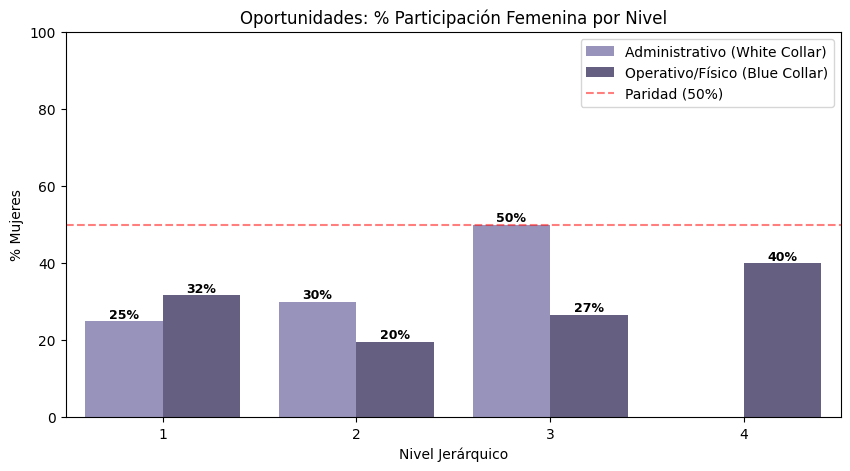

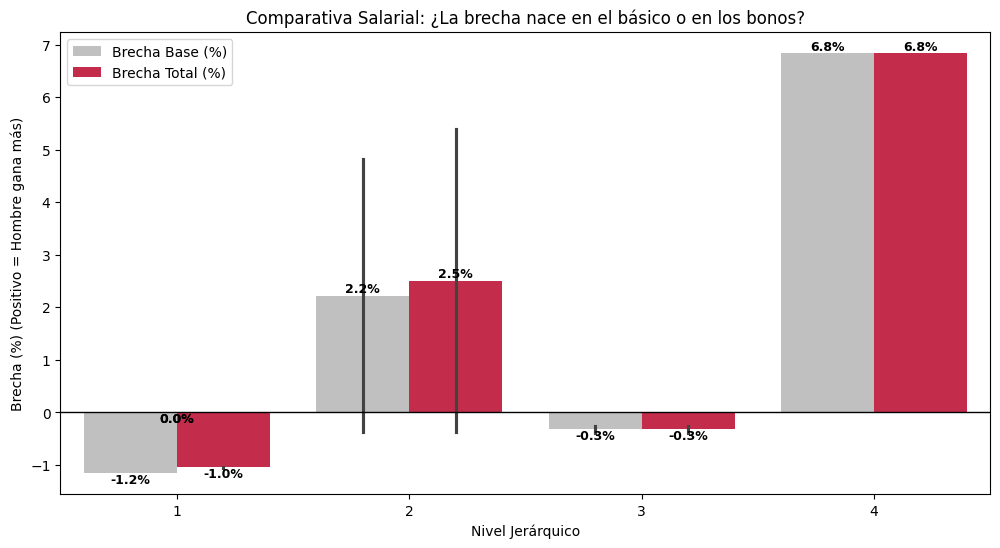

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INICIANDO ANÁLISIS PREGUNTA 3: EQUIDAD Y CULTURA")

# 1. Usamos la tabla que YA creamos en pasos anteriores
try:
    df_origen = headcount_acumulado.copy()
except NameError:
    print("ERROR: La tabla 'headcount_acumulado' no está en memoria. Por favor corre el Bloque 2.")

# 2. Filtrar la última foto activa (Headcount Actual)
latest_date = df_origen['mes_snapshot'].max()
df_current = df_origen[
    (df_origen['mes_snapshot'] == latest_date) &
    (df_origen['activo'] == True)
].copy()

# 3. Preparar Variables Financieras
# Rellenar nulos en bonos con 0
df_current['bonus_anual'] = df_current['bonus_anual'].fillna(0)
# Calcular Ingreso Total Mensualizado (Sueldo + Proporción de Bono)
df_current['total_mensual'] = df_current['salario_base_mensual'] + (df_current['bonus_anual'] / 12)

# 4. Clasificación Tipo de Trabajo (Manual vs Administrativo)
# Blue Collar = Manual, White Collar = Administrativo
df_current['tipo_trabajo'] = df_current['categoria_collar'].apply(
    lambda x: 'Operativo/Físico (Blue Collar)' if x == 'Blue' else 'Administrativo (White Collar)'
)

# 5. Función de Análisis de Brecha
def analizar_brecha(df, col_valor, nombre_metrica):
    # Agrupar por Tipo, Nivel y Género
    # observed=False previene warnings de categorías vacías
    resumen = df.groupby(['tipo_trabajo', 'nivel_jerarquico', 'genero'], observed=False).agg({
        col_valor: 'mean',
        'empleado_id': 'count'
    }).reset_index()

    # Pivotar para poner F y M en columnas
    pivot = resumen.pivot_table(
        index=['tipo_trabajo', 'nivel_jerarquico'],
        columns='genero',
        values=[col_valor, 'empleado_id']
    ).reset_index()

    # Aplanar y renombrar columnas
    pivot.columns = ['Tipo Trabajo', 'Nivel Jerárquico', 'Cant F', 'Cant M', 'Valor F', 'Valor M']
    pivot = pivot.fillna(0)

    # Métricas Base
    pivot['Total Personas'] = pivot['Cant F'] + pivot['Cant M']

    # Cálculo de Brecha: Diferencia porcentual respecto al hombre
    # (Hombre - Mujer) / Hombre
    def calc_gap(row):
        if row['Valor M'] > 0 and row['Valor F'] > 0:
            return ((row['Valor M'] - row['Valor F']) / row['Valor M']) * 100
        return None

    pivot[f'Brecha {nombre_metrica} (%)'] = pivot.apply(calc_gap, axis=1)
    return pivot

# 6. Ejecutar Análisis
# A. Brecha en Salario BASE
pivot_base = analizar_brecha(df_current, 'salario_base_mensual', 'Base')
# Aprovechamos para calcular % Mujeres aquí
pivot_base['% Mujeres'] = (pivot_base['Cant F'] / pivot_base['Total Personas']) * 100

# B. Brecha en Salario TOTAL (Con Bonos)
pivot_total = analizar_brecha(df_current, 'total_mensual', 'Total')

# 7. Unificar Resultados
resumen_final = pivot_base[['Tipo Trabajo', 'Nivel Jerárquico', 'Cant F', 'Cant M', '% Mujeres', 'Brecha Base (%)']].copy()
resumen_final['Brecha Total (%)'] = pivot_total['Brecha Total (%)']

print(f"Fecha de corte analizada: {latest_date.date()}")
print("--- TABLA COMPARATIVA: Impacto de Bonos y Jerarquía ---")
display(resumen_final.round(1))

# --- VISUALIZACIÓN ---

# Gráfico 1: Oportunidades (Techo de Cristal)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=pivot_base, x='Nivel Jerárquico', y='% Mujeres',
    hue='Tipo Trabajo', palette='Purples_d'
)
plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='Paridad (50%)')
plt.title('Oportunidades: % Participación Femenina por Nivel')
plt.ylabel('% Mujeres')
plt.ylim(0, 100) # Escala fija de 0 a 100%
plt.legend()

# Etiquetas
for p in plt.gca().patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(f'{h:.0f}%', (p.get_x() + p.get_width()/2., h),
                           ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.show()

# Gráfico 2: Brecha Salarial (Base vs Total)
# Transformar datos para graficar agrupado
df_melted = pd.melt(
    resumen_final,
    id_vars=['Tipo Trabajo', 'Nivel Jerárquico'],
    value_vars=['Brecha Base (%)', 'Brecha Total (%)'],
    var_name='Tipo de Brecha', value_name='Brecha (%)'
)
# Filtramos vacíos
df_melted = df_melted.dropna(subset=['Brecha (%)'])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_melted, x='Nivel Jerárquico', y='Brecha (%)',
    hue='Tipo de Brecha', palette={'Brecha Base (%)': 'silver', 'Brecha Total (%)': 'crimson'}
)
plt.axhline(0, color='black', linewidth=1)
plt.title('Comparativa Salarial: ¿La brecha nace en el básico o en los bonos?')
plt.ylabel('Brecha (%) (Positivo = Hombre gana más)')
plt.legend()

# Etiquetas con signo
for p in plt.gca().patches:
    h = p.get_height()
    if pd.notnull(h):
        plt.gca().annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2., h),
                           ha='center', va='bottom' if h>0 else 'top', fontsize=9, fontweight='bold')
plt.show()

--- INICIANDO ANÁLISIS PREGUNTA 4: ROI DE CAPACITACIÓN ---


--- RESULTADOS: IMPACTO EN SEGURIDAD (Blue Collar) ---
          Estado Capacitación  Promedio Incidentes (Mensual)  Total Registros  Personas Únicas
0     Capacitado en Seguridad                       0.005800              862               90
1  Sin Capacitación Seguridad                       0.014158             6145              447

--- RESULTADOS: IMPACTO EN PRODUCTIVIDAD (Blue Collar) ---
             Nivel Capacitación  Tasa Scrap Promedio (%)  Unidades Promedio  Total Registros  Personas Únicas
2      Sin Capacitación Técnica                     2.28             980.45             6290              446
1   Capacitación Básica (1-40h)                     2.33             992.40              269               31
0  Capacitación Avanzada (>40h)                     2.08             989.43              448               48


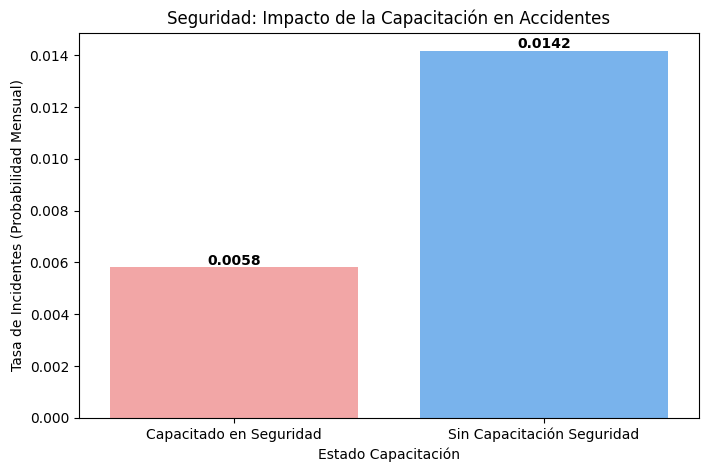

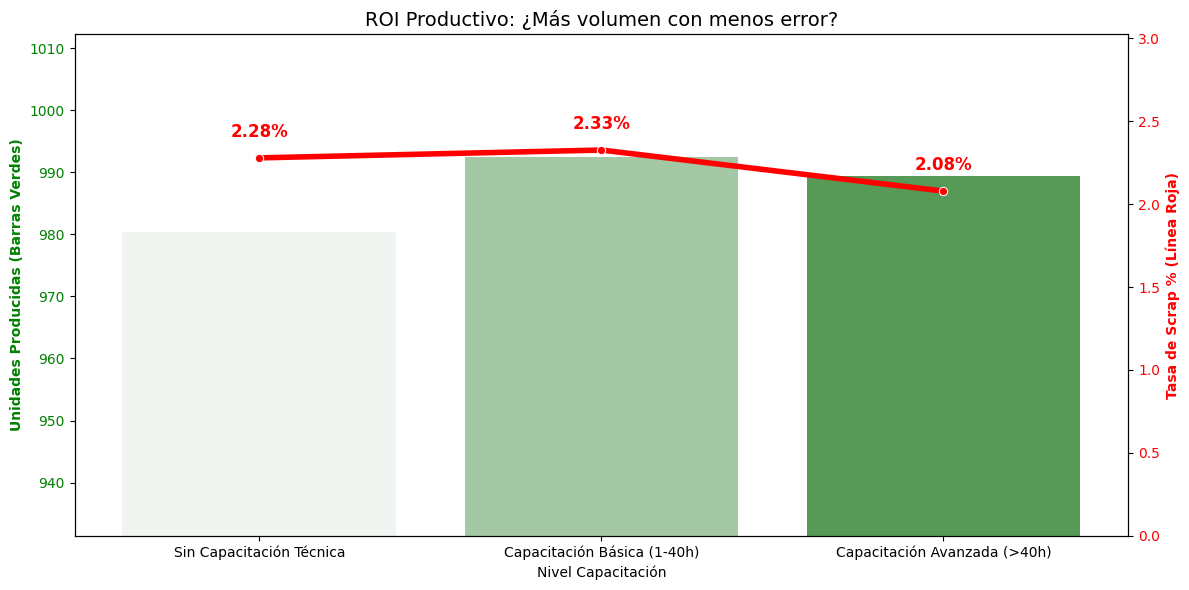

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INICIANDO ANÁLISIS PREGUNTA 4: ROI DE CAPACITACIÓN ---\n")

# 1. CARGA DE DATOS (Nombres cortos según tu solicitud)
# Asegúrate de que estos archivos estén en la misma carpeta
hc_acumulado = pd.read_csv('headcount_acumulado.csv', encoding='latin1')
capacitaciones_actual = pd.read_csv('capacitaciones_actual.csv', encoding='latin1')

# 2. LIMPIEZA DE FECHAS
hc_acumulado['mes_snapshot'] = pd.to_datetime(hc_acumulado['mes_snapshot'], errors='coerce')
capacitaciones_actual['fecha_fin'] = pd.to_datetime(capacitaciones_actual['fecha_fin'], errors='coerce')
# Creamos periodo mensual para cruzar datos
capacitaciones_actual['mes_fin_calc'] = capacitaciones_actual['fecha_fin'].dt.to_period('M')

# ---------------------------------------------------------
# ANÁLISIS A: IMPACTO EN SEGURIDAD (ROI)
# ---------------------------------------------------------

# 1. Filtramos cursos de Seguridad
cap_seguridad = capacitaciones_actual[capacitaciones_actual['categoria_training'] == 'Seguridad'].copy()

# 2. Creamos log de cuándo se capacitó cada empleado
training_log = cap_seguridad.groupby(['empleado_id', 'mes_fin_calc']).size().reset_index(name='cursos_seguridad_mes')
training_log['mes_snapshot'] = training_log['mes_fin_calc'].dt.to_timestamp()

# 3. Cruzamos con la historia del empleado (Headcount Acumulado)
hc_con_training = pd.merge(
    hc_acumulado[['empleado_id', 'mes_snapshot', 'incidentes_seguridad_count', 'categoria_collar']],
    training_log[['empleado_id', 'mes_snapshot', 'cursos_seguridad_mes']],
    on=['empleado_id', 'mes_snapshot'],
    how='left'
)

# 4. Calculamos acumulado para ver estado real en cada mes
hc_con_training['cursos_seguridad_mes'] = hc_con_training['cursos_seguridad_mes'].fillna(0)
hc_con_training = hc_con_training.sort_values(['empleado_id', 'mes_snapshot'])
hc_con_training['cursos_seguridad_acum'] = hc_con_training.groupby('empleado_id')['cursos_seguridad_mes'].cumsum()

# Definimos estado: Si tiene >0 cursos acumulados, ya está capacitado
hc_con_training['estado_capacitacion'] = hc_con_training['cursos_seguridad_acum'].apply(
    lambda x: 'Capacitado en Seguridad' if x > 0 else 'Sin Capacitación Seguridad'
)

# 5. Filtramos solo Operarios (Blue Collar)
hc_seguridad_blue = hc_con_training[hc_con_training['categoria_collar'] == 'Blue'].copy()

# 6. KPI Final Seguridad
resumen_seguridad = hc_seguridad_blue.groupby('estado_capacitacion', observed=False).agg({
    'incidentes_seguridad_count': 'mean',
    'empleado_id': ['count', 'nunique']
}).reset_index()

resumen_seguridad.columns = ['Estado Capacitación', 'Promedio Incidentes (Mensual)', 'Total Registros', 'Personas Únicas']

print("\n--- RESULTADOS: IMPACTO EN SEGURIDAD (Blue Collar) ---")
print(resumen_seguridad.to_string())

# ---------------------------------------------------------
# ANÁLISIS B: IMPACTO EN PRODUCTIVIDAD (ROI)
# ---------------------------------------------------------

# 1. Filtramos cursos Técnicos, Calidad o Gestión
cap_tecnica = capacitaciones_actual[capacitaciones_actual['categoria_training'].isin(['Técnico', 'Calidad', 'Gestión'])].copy()

# 2. Sumamos horas técnicas por mes
tech_log = cap_tecnica.groupby(['empleado_id', 'mes_fin_calc'])['duracion_horas'].sum().reset_index(name='horas_tech_mes')
tech_log['mes_snapshot'] = tech_log['mes_fin_calc'].dt.to_timestamp()

# 3. Merge con historia productiva
hc_con_tech = pd.merge(
    hc_acumulado[['empleado_id', 'mes_snapshot', 'tasa_scrap_porcentaje', 'unidades_producidas', 'categoria_collar']],
    tech_log[['empleado_id', 'mes_snapshot', 'horas_tech_mes']],
    on=['empleado_id', 'mes_snapshot'],
    how='left'
)
hc_con_tech['horas_tech_mes'] = hc_con_tech['horas_tech_mes'].fillna(0)
hc_con_tech = hc_con_tech.sort_values(['empleado_id', 'mes_snapshot'])
hc_con_tech['horas_tech_acum'] = hc_con_tech.groupby('empleado_id')['horas_tech_mes'].cumsum()

# 4. Clasificación por nivel de horas acumuladas
def clasificar_tech(horas):
    if horas == 0: return 'Sin Capacitación Técnica'
    elif horas <= 40: return 'Capacitación Básica (1-40h)'
    else: return 'Capacitación Avanzada (>40h)'

hc_con_tech['nivel_capacitacion'] = hc_con_tech['horas_tech_acum'].apply(clasificar_tech)
hc_tech_blue = hc_con_tech[hc_con_tech['categoria_collar'] == 'Blue'].copy()

# 5. KPI Final Productividad
resumen_prod = hc_tech_blue.groupby('nivel_capacitacion', observed=False).agg({
    'tasa_scrap_porcentaje': 'mean',
    'unidades_producidas': 'mean',
    'empleado_id': ['count', 'nunique']
}).reset_index()

resumen_prod.columns = ['Nivel Capacitación', 'Tasa Scrap Promedio (%)', 'Unidades Promedio', 'Total Registros', 'Personas Únicas']

# Ordenar
orden_niveles = ['Sin Capacitación Técnica', 'Capacitación Básica (1-40h)', 'Capacitación Avanzada (>40h)']
resumen_prod['Nivel Capacitación'] = pd.Categorical(resumen_prod['Nivel Capacitación'], categories=orden_niveles, ordered=True)
resumen_prod = resumen_prod.sort_values('Nivel Capacitación')

print("\n--- RESULTADOS: IMPACTO EN PRODUCTIVIDAD (Blue Collar) ---")
print(resumen_prod.round(2).to_string())

# ---------------------------------------------------------
# VISUALIZACIÓN
# ---------------------------------------------------------

# Gráfico 1: Seguridad
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=resumen_seguridad, x='Estado Capacitación', y='Promedio Incidentes (Mensual)',
    hue='Estado Capacitación', palette=['#ff9999', '#66b3ff']
)
# Eliminar leyenda si estorba
if ax.legend_: ax.legend_.remove()

plt.title('Seguridad: Impacto de la Capacitación en Accidentes')
plt.ylabel('Tasa de Incidentes (Probabilidad Mensual)')
# Etiquetas de valor
for p in plt.gca().patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(f'{h:.4f}', (p.get_x() + p.get_width()/2., h),
                           ha='center', va='bottom', fontweight='bold')
plt.show()

# Gráfico 2: Productividad (Doble Eje)
plt.figure(figsize=(12, 6))
ax1 = plt.gca()

# Barras: Unidades
sns.barplot(
    data=resumen_prod, x='Nivel Capacitación', y='Unidades Promedio',
    hue='Nivel Capacitación', palette='light:green', ax=ax1, alpha=0.7
)
if ax1.legend_: ax1.legend_.remove()

ax1.set_ylabel('Unidades Producidas (Barras Verdes)', color='green', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='green')
# Zoom para ver mejor las diferencias
min_u = resumen_prod['Unidades Promedio'].min() * 0.95
max_u = resumen_prod['Unidades Promedio'].max() * 1.02
ax1.set_ylim(min_u, max_u)

# Línea: Scrap
ax2 = ax1.twinx()
sns.lineplot(
    data=resumen_prod, x='Nivel Capacitación', y='Tasa Scrap Promedio (%)',
    ax=ax2, color='red', marker='o', linewidth=4, sort=False
)
ax2.set_ylabel('Tasa de Scrap % (Línea Roja)', color='red', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, resumen_prod['Tasa Scrap Promedio (%)'].max() * 1.3)

plt.title('ROI Productivo: ¿Más volumen con menos error?', fontsize=14)
# Etiquetas en la línea roja
for i, txt in enumerate(resumen_prod['Tasa Scrap Promedio (%)']):
    ax2.annotate(f"{txt:.2f}%", (i, txt), xytext=(0, 15), textcoords='offset points',
                 ha='center', color='red', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

--- INICIANDO ANÁLISIS ROI: DOBLE CLICK POR CATEGORÍA ---

Distribución Real de Categorías:
nueva_categoria
Técnica       212
Onboarding    171
Calidad       106
Seguridad      72
Name: count, dtype: int64
------------------------------

--- ROI SEGURIDAD ---


,Estado (Seguridad),Tasa Incidentes,Personas Únicas
0,Capacitado,0.005119,61
1,No Capacitado,0.013861,453



--- ROI CALIDAD (SCRAP) ---


,Nivel (Cursos Calidad),Tasa Scrap %,Personas Únicas
2,Sin Curso Calidad,2.296133,446
1,Experto (>20h),1.914164,40
0,Básico (1-20h),NaN,16



--- ROI TÉCNICA (PRODUCTIVIDAD) ---


,Nivel (Cursos Técnicos),Unidades Promedio,Personas Únicas
0,Sin Curso Técnico,979.972881,443
1,Técnico Avanzado (>40h),984.250000,127
2,Técnico Básico (1-40h),991.419453,41


/tmp/ipython-input-3077682794.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_seg, x='Estado (Seguridad)', y='Tasa Incidentes', ax=axes[0], palette=['#ff9999', '#66b3ff'])
/tmp/ipython-input-3077682794.py:165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_cal, x='Nivel (Cursos Calidad)', y='Tasa Scrap %', ax=axes[1], palette='Reds')
/tmp/ipython-input-3077682794.py:171: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_tec, x='Nivel (Cursos Técnicos)', y='Unidades Promedio', ax=axes[2], palette='Green

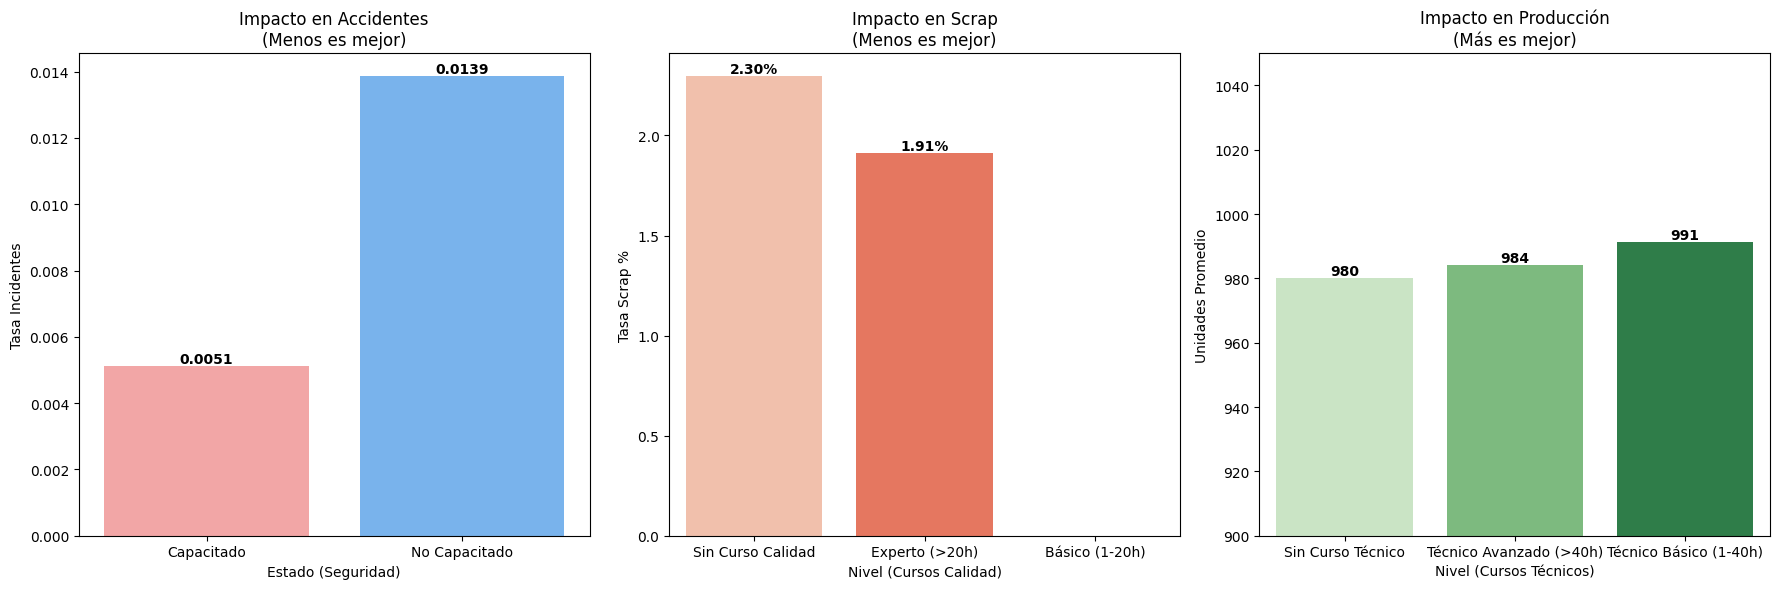

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INICIANDO ANÁLISIS ROI: DOBLE CLICK POR CATEGORÍA ---\n")

# 1. CARGA DE DATOS
hc_acumulado = pd.read_csv('headcount_acumulado.csv', encoding='latin1')
capacitaciones = pd.read_csv('capacitaciones_actual.csv', encoding='latin1')

# 2. LIMPIEZA DE CARACTERES (CRÍTICO para que el mapeo funcione)
def arreglar_caracteres(serie):
    reemplazos = {
        'Ã¡': 'á', 'Ã©': 'é', 'Ã\xad': 'í', 'Ã-': 'í',
        'Ã³': 'ó', 'Ãº': 'ú', 'Ã±': 'ñ', 'Ã\x81': 'Á', 'Ã': 'Á',
    }
    for mal, bien in reemplazos.items():
        serie = serie.str.replace(mal, bien, regex=False)
    return serie

capacitaciones['tipo_training'] = arreglar_caracteres(capacitaciones['tipo_training'])

# 3. MAPEO DE CATEGORÍAS (Tu lista validada)
mapeo_categorias = {
    # SEGURIDAD (Impacto en Accidentes)
    'Seguridad en Prensas': 'Seguridad',
    'Seguridad Eléctrica': 'Seguridad',
    'Alta Tensión': 'Seguridad',
    'Mantenimiento Preventivo': 'Seguridad',

    # TÉCNICA (Impacto en Unidades/Eficiencia)
    'Advanced Welding Certification (AWS)': 'Técnica',
    'Setup de Prensa - Básico': 'Técnica',
    'Setup de Prensa - Avanzado': 'Técnica',
    'Soldadura MIG/MAG - Básico': 'Técnica',
    'Soldadura MIG/TIG Básica': 'Técnica',
    'Ensamble de Componentes': 'Técnica',
    'Preparación de Superficie': 'Técnica',
    'Aplicación de Pintura': 'Técnica',
    'Hidráulica': 'Técnica',
    'Neumática': 'Técnica',
    'Alineación Laser': 'Técnica',
    'PLC - Programación': 'Técnica',
    'Certificación Eléctrica Básica': 'Técnica',

    # CALIDAD (Impacto en Scrap)
    'Control de Calidad en Línea': 'Calidad',
    'Control de Calidad Pintura': 'Calidad',
    'SPC - Control Estadístico': 'Calidad',
    'Auditoría Interna ISO': 'Calidad',
    'Metrología': 'Calidad',
    'ISO 9001 Básico': 'Calidad',

    # ONBOARDING (No se mide ROI productivo)
    'Inducción General': 'Onboarding',
    'Capacitación General': 'Onboarding'
}

capacitaciones['nueva_categoria'] = capacitaciones['tipo_training'].map(mapeo_categorias).fillna('OTROS')

# Verificación rápida
print("Distribución Real de Categorías:")
print(capacitaciones['nueva_categoria'].value_counts())
print("-" * 30)

# Preparación de fechas
hc_acumulado['mes_snapshot'] = pd.to_datetime(hc_acumulado['mes_snapshot'], errors='coerce')
capacitaciones['fecha_fin'] = pd.to_datetime(capacitaciones['fecha_fin'], errors='coerce')
capacitaciones['mes_fin_calc'] = capacitaciones['fecha_fin'].dt.to_period('M')

# ==============================================================================
# ANÁLISIS 1: SEGURIDAD (Solo cursos 'Seguridad' vs Incidentes)
# ==============================================================================
cap_seg = capacitaciones[capacitaciones['nueva_categoria'] == 'Seguridad'].copy()
log_seg = cap_seg.groupby(['empleado_id', 'mes_fin_calc']).size().reset_index(name='cursos_mes')
log_seg['mes_snapshot'] = log_seg['mes_fin_calc'].dt.to_timestamp()

hc_seg = pd.merge(
    hc_acumulado[['empleado_id', 'mes_snapshot', 'incidentes_seguridad_count', 'categoria_collar']],
    log_seg[['empleado_id', 'mes_snapshot', 'cursos_mes']],
    on=['empleado_id', 'mes_snapshot'], how='left'
).fillna({'cursos_mes': 0}).sort_values(['empleado_id', 'mes_snapshot'])

hc_seg['acumulado'] = hc_seg.groupby('empleado_id')['cursos_mes'].cumsum()
hc_seg['Estado'] = hc_seg['acumulado'].apply(lambda x: 'Capacitado' if x > 0 else 'No Capacitado')

# KPI (Solo Operarios Blue Collar)
resumen_seg = hc_seg[hc_seg['categoria_collar'] == 'Blue'].groupby('Estado', observed=False).agg({
    'incidentes_seguridad_count': 'mean',
    'empleado_id': 'nunique'
}).reset_index()
resumen_seg.columns = ['Estado (Seguridad)', 'Tasa Incidentes', 'Personas Únicas']

print("\n--- ROI SEGURIDAD ---")
display(resumen_seg)


# ==============================================================================
# ANÁLISIS 2: CALIDAD (Solo cursos 'Calidad' vs Scrap)
# ==============================================================================
cap_cal = capacitaciones[capacitaciones['nueva_categoria'] == 'Calidad'].copy()
log_cal = cap_cal.groupby(['empleado_id', 'mes_fin_calc'])['duracion_horas'].sum().reset_index(name='horas_mes')
log_cal['mes_snapshot'] = log_cal['mes_fin_calc'].dt.to_timestamp()

hc_cal = pd.merge(
    hc_acumulado[['empleado_id', 'mes_snapshot', 'tasa_scrap_porcentaje', 'categoria_collar']],
    log_cal[['empleado_id', 'mes_snapshot', 'horas_mes']],
    on=['empleado_id', 'mes_snapshot'], how='left'
).fillna({'horas_mes': 0}).sort_values(['empleado_id', 'mes_snapshot'])

hc_cal['acumulado'] = hc_cal.groupby('empleado_id')['horas_mes'].cumsum()
hc_cal['Nivel'] = hc_cal['acumulado'].apply(
    lambda h: 'Sin Curso Calidad' if h == 0 else ('Básico (1-20h)' if h <= 20 else 'Experto (>20h)')
)

resumen_cal = hc_cal[hc_cal['categoria_collar'] == 'Blue'].groupby('Nivel', observed=False).agg({
    'tasa_scrap_porcentaje': 'mean',
    'empleado_id': 'nunique'
}).reset_index().sort_values('tasa_scrap_porcentaje', ascending=False)
resumen_cal.columns = ['Nivel (Cursos Calidad)', 'Tasa Scrap %', 'Personas Únicas']

print("\n--- ROI CALIDAD (SCRAP) ---")
display(resumen_cal)


# ==============================================================================
# ANÁLISIS 3: TÉCNICA (Solo cursos 'Técnica' vs Unidades)
# ==============================================================================
cap_tec = capacitaciones[capacitaciones['nueva_categoria'] == 'Técnica'].copy()
log_tec = cap_tec.groupby(['empleado_id', 'mes_fin_calc'])['duracion_horas'].sum().reset_index(name='horas_mes')
log_tec['mes_snapshot'] = log_tec['mes_fin_calc'].dt.to_timestamp()

hc_tec = pd.merge(
    hc_acumulado[['empleado_id', 'mes_snapshot', 'unidades_producidas', 'categoria_collar']],
    log_tec[['empleado_id', 'mes_snapshot', 'horas_mes']],
    on=['empleado_id', 'mes_snapshot'], how='left'
).fillna({'horas_mes': 0}).sort_values(['empleado_id', 'mes_snapshot'])

hc_tec['acumulado'] = hc_tec.groupby('empleado_id')['horas_mes'].cumsum()
hc_tec['Nivel'] = hc_tec['acumulado'].apply(
    lambda h: 'Sin Curso Técnico' if h == 0 else ('Técnico Básico (1-40h)' if h <= 40 else 'Técnico Avanzado (>40h)')
)

resumen_tec = hc_tec[hc_tec['categoria_collar'] == 'Blue'].groupby('Nivel', observed=False).agg({
    'unidades_producidas': 'mean',
    'empleado_id': 'nunique'
}).reset_index().sort_values('unidades_producidas')
resumen_tec.columns = ['Nivel (Cursos Técnicos)', 'Unidades Promedio', 'Personas Únicas']

print("\n--- ROI TÉCNICA (PRODUCTIVIDAD) ---")
display(resumen_tec)

# ==============================================================================
# VISUALIZACIÓN
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Seguridad
sns.barplot(data=resumen_seg, x='Estado (Seguridad)', y='Tasa Incidentes', ax=axes[0], palette=['#ff9999', '#66b3ff'])
axes[0].set_title('Impacto en Accidentes\n(Menos es mejor)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width()/2., p.get_height()), ha='center', va='bottom', fontweight='bold')

# Plot 2: Calidad
sns.barplot(data=resumen_cal, x='Nivel (Cursos Calidad)', y='Tasa Scrap %', ax=axes[1], palette='Reds')
axes[1].set_title('Impacto en Scrap\n(Menos es mejor)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width()/2., p.get_height()), ha='center', va='bottom', fontweight='bold')

# Plot 3: Técnica
sns.barplot(data=resumen_tec, x='Nivel (Cursos Técnicos)', y='Unidades Promedio', ax=axes[2], palette='Greens')
axes[2].set_title('Impacto en Producción\n(Más es mejor)')
axes[2].set_ylim(900, 1050) # Zoom
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width()/2., p.get_height()), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

--- INICIANDO ANÁLISIS PREGUNTA 5: SEGURIDAD Y COSTOS ---


--- RESUMEN EJECUTIVO DE SEGURIDAD ---
Total Incidentes Registrados: 43
Total Días Perdidos: 113
Costo Directo (Daños/Médico): $870,000.00
Costo Indirecto (Salarios Caídos): $6,973,377.96
COSTO TOTAL ESTIMADO: $7,843,377.96

--- RIESGO POR HORAS EXTRA ---
Nivel Horas Extra  Promedio Incidentes  Total Registros  Tasa Riesgo %
     Sin H.E. (0)             0.000000                3       0.000000
     Bajo (1-10h)             0.008184             2566       0.818394
   Medio (10-20h)             0.014778             4263       1.477833
      Alto (>20h)             0.045714              175       4.571429


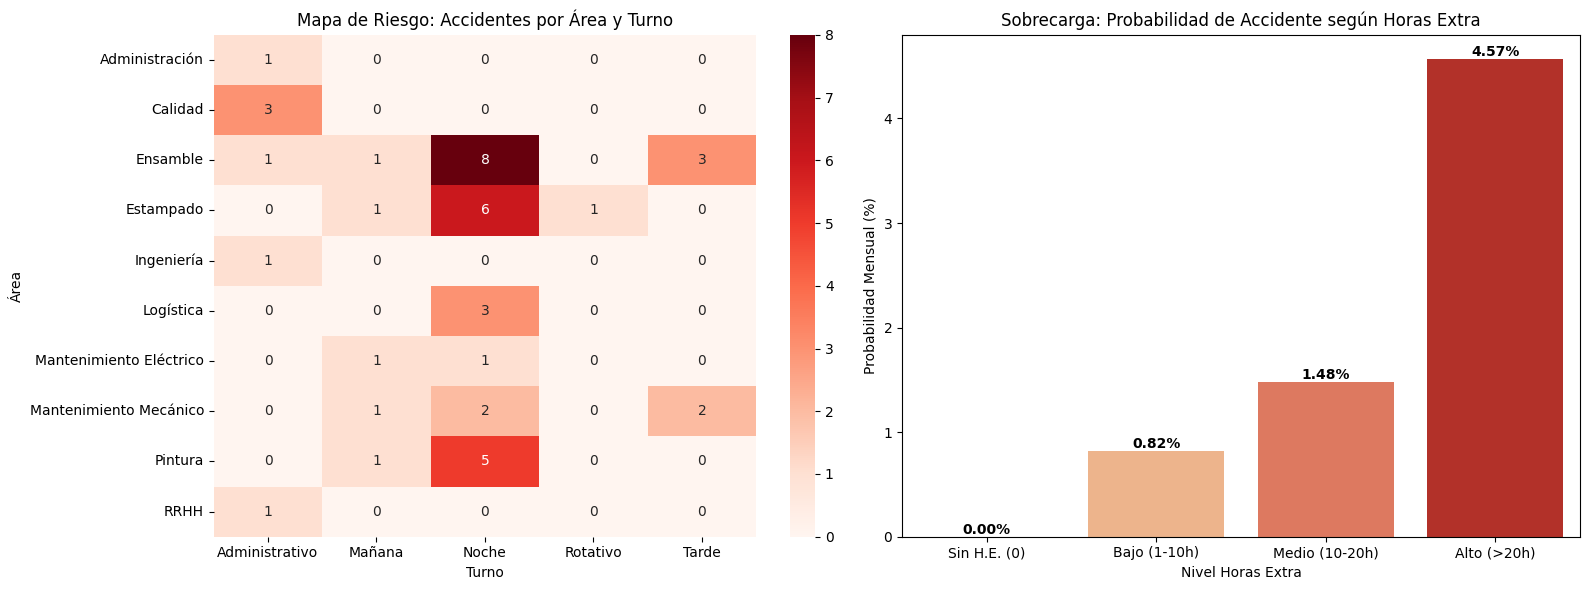

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INICIANDO ANÁLISIS PREGUNTA 5: SEGURIDAD Y COSTOS ---\n")

# 1. CARGA DE DATOS
# Asegúrate de tener 'headcount_acumulado.csv' y 'eventos_actual.csv' en la misma carpeta
hc_acumulado = pd.read_csv('headcount_acumulado.csv', encoding='latin1')
eventos_actual = pd.read_csv('eventos_actual.csv', encoding='latin1')

# --- CORRECCIÓN 1: LIMPIEZA DE CARACTERES ---
def arreglar_caracteres(texto):
    if not isinstance(texto, str):
        return texto
    reemplazos = {
        'Ã¡': 'á', 'Ã©': 'é', 'Ã\xad': 'í', 'Ã-': 'í',
        'Ã³': 'ó', 'Ãº': 'ú', 'Ã±': 'ñ', 'Ã\x81': 'Á',
        'Ã': 'Á', 'Ã\x91': 'Ñ', 'Ã\x89': 'É'
    }
    for mal, bien in reemplazos.items():
        texto = texto.replace(mal, bien)
    return texto

# Aplicamos la limpieza a las columnas de texto clave en ambos archivos
cols_limpiar_eventos = ['area_empleado', 'turno_evento', 'tipo_evento']
for col in cols_limpiar_eventos:
    if col in eventos_actual.columns:
        eventos_actual[col] = eventos_actual[col].apply(arreglar_caracteres)

cols_limpiar_hc = ['area_empleado', 'categoria_collar']
for col in cols_limpiar_hc:
    if col in hc_acumulado.columns:
        hc_acumulado[col] = hc_acumulado[col].apply(arreglar_caracteres)
# -----------------------------------------------------------

# 2. LIMPIEZA DE FECHAS
hc_acumulado['mes_snapshot'] = pd.to_datetime(hc_acumulado['mes_snapshot'], errors='coerce')
eventos_actual['fecha_evento'] = pd.to_datetime(eventos_actual['fecha_evento'], errors='coerce')

# ------------------------------------------------------------------
# ANÁLISIS 1: FOCOS DE RIESGO (Área + Turno)
# ------------------------------------------------------------------

# Filtramos incidentes de seguridad
incidentes = eventos_actual[eventos_actual['tipo_evento'] == 'incidente_seguridad'].copy()

# Agrupamos por Área y Turno para ver dónde ocurren
heatmap_data = incidentes.groupby(['area_empleado', 'turno_evento']).size().reset_index(name='total_incidentes')

# Creamos matriz pivot para el heatmap
pivot_risk = heatmap_data.pivot(index='area_empleado', columns='turno_evento', values='total_incidentes').fillna(0)

# ------------------------------------------------------------------
# ANÁLISIS 2: HORAS EXTRA vs INCIDENTES (La causa raíz)
# ------------------------------------------------------------------

# Usamos HC Acumulado que tiene el historial mes a mes
# Filtramos solo operarios (Blue Collar) que tienen riesgo físico
df_risk = hc_acumulado[hc_acumulado['categoria_collar'] == 'Blue'].copy()

# Creamos categorías (buckets) de Horas Extra
bins = [-1, 0, 10, 20, 1000]
labels = ['Sin H.E. (0)', 'Bajo (1-10h)', 'Medio (10-20h)', 'Alto (>20h)']
df_risk['nivel_extra'] = pd.cut(df_risk['horas_extra'], bins=bins, labels=labels)

# Calculamos la tasa de riesgo (% de empleados que se accidentan en cada nivel)
risk_overtime = df_risk.groupby('nivel_extra', observed=False).agg({
    'incidentes_seguridad_count': 'mean',
    'empleado_id': 'count'
}).reset_index()

# Convertimos a porcentaje para facilitar lectura
risk_overtime['tasa_riesgo_pct'] = risk_overtime['incidentes_seguridad_count'] * 100
risk_overtime.columns = ['Nivel Horas Extra', 'Promedio Incidentes', 'Total Registros', 'Tasa Riesgo %']

# ------------------------------------------------------------------
# ANÁLISIS 3: COSTO FINANCIERO ESTIMADO
# ------------------------------------------------------------------

# A. Costo Directo (Lo que reportamos al seguro/mantenimiento)
costo_directo = incidentes['costo_estimado'].sum()
dias_perdidos_total = incidentes['dias_perdidos'].sum()

# B. Costo Indirecto (Salarios pagados por días no trabajados)
# Obtenemos salario promedio actual de operarios para estimar el costo del día perdido
salario_promedio_blue = hc_acumulado[
    (hc_acumulado['categoria_collar'] == 'Blue') &
    (hc_acumulado['mes_snapshot'] == hc_acumulado['mes_snapshot'].max())
]['salario_base_mensual'].mean()

costo_dia_promedio = salario_promedio_blue / 30
costo_indirecto = dias_perdidos_total * costo_dia_promedio

costo_total = costo_directo + costo_indirecto

# IMPRIMIR RESULTADOS
print("\n--- RESUMEN EJECUTIVO DE SEGURIDAD ---")
print(f"Total Incidentes Registrados: {len(incidentes)}")
print(f"Total Días Perdidos: {dias_perdidos_total}")
print(f"Costo Directo (Daños/Médico): ${costo_directo:,.2f}")
print(f"Costo Indirecto (Salarios Caídos): ${costo_indirecto:,.2f}")
print(f"COSTO TOTAL ESTIMADO: ${costo_total:,.2f}")

print("\n--- RIESGO POR HORAS EXTRA ---")
print(risk_overtime.to_string(index=False))

# ------------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Mapa de Calor
sns.heatmap(pivot_risk, annot=True, fmt='g', cmap='Reds', ax=axes[0])
axes[0].set_title('Mapa de Riesgo: Accidentes por Área y Turno')
axes[0].set_ylabel('Área')
axes[0].set_xlabel('Turno')

# Gráfico 2: Barras de Riesgo por Horas Extra
# --- CORRECCIÓN 2: SEABORN WARNING FIX (Agregado hue y legend=False) ---
sns.barplot(
    data=risk_overtime,
    x='Nivel Horas Extra',
    y='Tasa Riesgo %',
    ax=axes[1],
    palette='OrRd',
    hue='Nivel Horas Extra',  # <--- FIX
    legend=False              # <--- FIX
)
axes[1].set_title('Sobrecarga: Probabilidad de Accidente según Horas Extra')
axes[1].set_ylabel('Probabilidad Mensual (%)')

# Etiquetas de valor en las barras
for p in axes[1].patches:
    height = p.get_height()
    # Verificación extra para evitar errores con valores nulos o cero si los hubiera
    if pd.notna(height):
        axes[1].annotate(f'{height:.2f}%',
                         (p.get_x() + p.get_width()/2., height),
                         ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()